In [16]:
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Laadt de Fashion-MNIST dataset voor training en testen
from tensorflow.keras.datasets import fashion_mnist

# Zet vaste seeds zodat random keuzes, zoals startgewichten, reproduceerbaar zijn
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

In [17]:
# Laadt Fashion-MNIST en splitst dit in train- en testdata
(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

In [18]:
# Koppelt elk labelnummer aan een kledingcategorie
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

In [19]:
# data shape: aantal afbeeldingen en grootte per afbeelding
# labels shape: aantal bijbehorende labels
print("Train data shape:", train_data.shape)
print("Train labels shape:", train_labels.shape)
print("Test data shape:", test_data.shape)
print("Test labels shape:", test_labels.shape)

# Controleert dat de labels lopen van 0 t/m 9
# Dit betekent 10 klassen, omdat 0 ook meetelt
print("Minimum label:", train_labels.min())
print("Maximum label:", train_labels.max())
print("Unieke labels:", np.unique(train_labels))

Train data shape: (60000, 28, 28)
Train labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)
Minimum label: 0
Maximum label: 9
Unieke labels: [0 1 2 3 4 5 6 7 8 9]


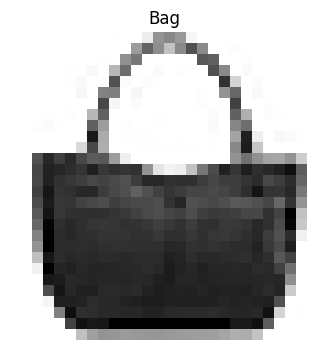

In [20]:
# Kiest afbeelding 100 uit de trainingsdata
index_of_choice = 100

plt.figure(figsize=(4, 4))
plt.imshow(train_data[index_of_choice], cmap=plt.cm.binary)

# Toont de kledingnaam die hoort bij het label van deze afbeelding
plt.title(class_names[train_labels[index_of_choice]])

plt.axis("off")
plt.show()

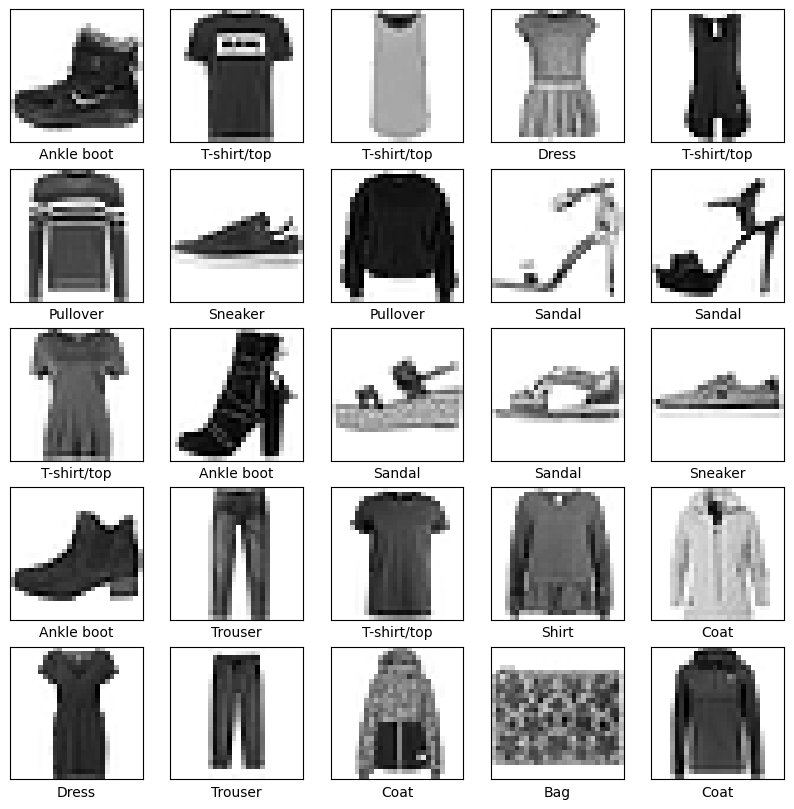

In [21]:
# Toont de eerste 25 trainingsafbeeldingen in een 5x5 overzicht
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_data[i], cmap=plt.cm.binary)

    # Zet de juiste kledingcategorie onder elke afbeelding
    plt.xlabel(class_names[train_labels[i]])

plt.show()

In [22]:
# Maakt een neural network waarbij de lagen achter elkaar worden uitgevoerd
model_1 = tf.keras.Sequential([
    # Geeft aan dat elke input-afbeelding 28x28 pixels is
    tf.keras.layers.Input(shape=(28, 28)),

    # Zet de 2D-afbeelding om naar één lange lijst van pixels
    tf.keras.layers.Flatten(),

    # Hidden layers die patronen in de pixels leren
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),

    # Output layer met 10 neuronen, één voor elke kledingcategorie
    # softmax zet de uitkomst om naar kansen per klasse
    tf.keras.layers.Dense(10, activation="softmax")
])

# Stelt in hoe het model leert en hoe prestaties worden gemeten
model_1.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

# Traint het model met niet-genormaliseerde pixelwaarden
non_norm_history = model_1.fit(
    train_data,
    train_labels,
    epochs=10,
    validation_data=(test_data, test_labels)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1472 - loss: 2.2399 - val_accuracy: 0.2072 - val_loss: 2.0243
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2517 - loss: 1.7791 - val_accuracy: 0.2994 - val_loss: 1.7017
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2871 - loss: 1.6667 - val_accuracy: 0.3116 - val_loss: 1.6429
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3113 - loss: 1.6162 - val_accuracy: 0.3204 - val_loss: 1.6009
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3397 - loss: 1.5560 - val_accuracy: 0.3475 - val_loss: 1.5486
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3510 - loss: 1.5242 - val_accuracy: 0.3602 - val_loss: 1.5279
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3616 - loss: 1.4946 - val_accuracy: 0.3728 - val_loss: 1.5128
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3877 - loss: 1.4526 - 

In [23]:
# Test het model op data die het nog niet heeft gebruikt tijdens training
# Geeft de loss en accuracy terug
model_1.evaluate(test_data, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4377 - loss: 1.3861


[1.3861364126205444, 0.4377000033855438]

In [24]:
# Normaliseert pixelwaarden van 0-255 naar 0-1
# Dit helpt het model stabieler en vaak sneller te leren
train_data_norm = train_data.astype("float32") / 255.0
test_data_norm = test_data.astype("float32") / 255.0

In [25]:
# Zelfde modelstructuur als model_1, maar nu voor genormaliseerde data
model_4 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),

    # Hidden layers leren patronen uit de pixelwaarden
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),

    # Output layer: 10 kansen, één per kledingcategorie
    tf.keras.layers.Dense(10, activation="softmax")
])

# Compile stelt de loss, optimizer en accuracy-meting in
model_4.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

# Traint het model met genormaliseerde pixelwaarden
norm_history = model_4.fit(
    train_data_norm,
    train_labels,
    epochs=10,
    validation_data=(test_data_norm, test_labels)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5178 - loss: 1.3074 - val_accuracy: 0.6542 - val_loss: 0.9570
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6755 - loss: 0.8739 - val_accuracy: 0.7264 - val_loss: 0.8403
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7442 - loss: 0.7597 - val_accuracy: 0.7401 - val_loss: 0.7527
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7539 - loss: 0.6942 - val_accuracy: 0.7512 - val_loss: 0.7132
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7602 - loss: 0.6660 - val_accuracy: 0.7589 - val_loss: 0.6943
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7648 - loss: 0.6494 - val_accuracy: 0.7619 - val_loss: 0.6774
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7701 - loss: 0.6335 - val_accuracy: 0.7639 - val_loss: 0.6653
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7734 - loss: 0.6217 - 

In [26]:
model_4.evaluate(test_data_norm, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7710 - loss: 0.6454


[0.6453515887260437, 0.7710000276565552]

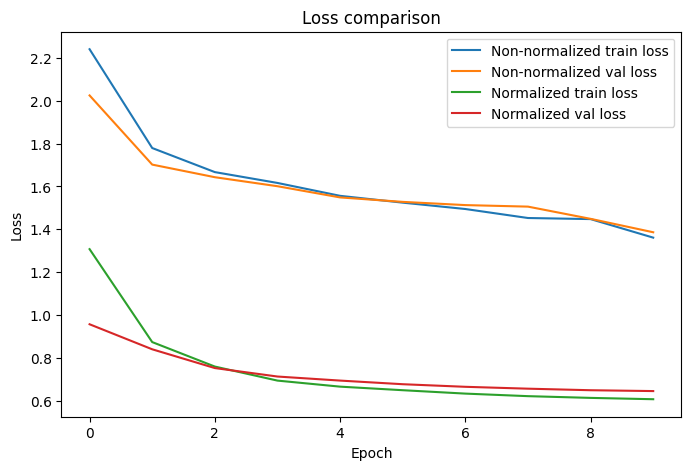

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(non_norm_history.history["loss"], label="Non-normalized train loss")
plt.plot(non_norm_history.history["val_loss"], label="Non-normalized val loss")
plt.plot(norm_history.history["loss"], label="Normalized train loss")
plt.plot(norm_history.history["val_loss"], label="Normalized val loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss comparison")
plt.legend()
plt.show()

In [28]:
pred_probs = model_4.predict(test_data_norm)
y_pred = pred_probs.argmax(axis=1)

print("Eerste voorspelling:", y_pred[0])
print("Echte label:", test_labels[0])
print("Voorspelde klasse:", class_names[y_pred[0]])
print("Echte klasse:", class_names[test_labels[0]])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Eerste voorspelling: 9
Echte label: 9
Voorspelde klasse: Ankle boot
Echte klasse: Ankle boot


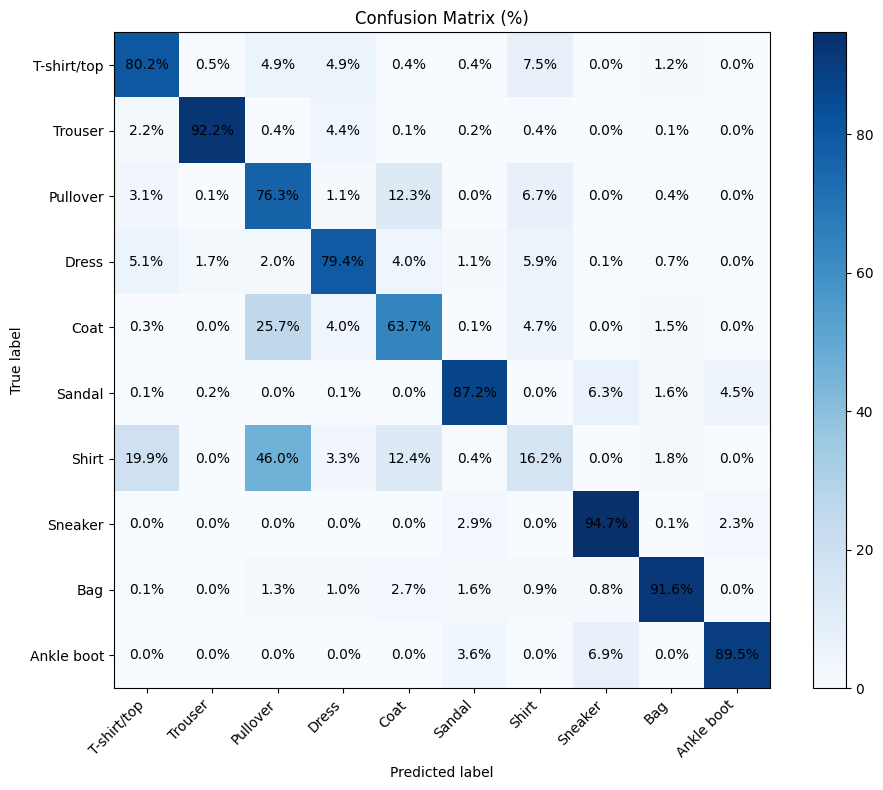

In [29]:
cm = tf.math.confusion_matrix(
    labels=test_labels,
    predictions=y_pred,
    num_classes=len(class_names)
).numpy()

cm_percent = cm.astype("float32") / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(10, 8))
plt.imshow(cm_percent, cmap="Blues")
plt.title("Confusion Matrix (%)")
plt.colorbar()

plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j, i,
            f"{cm_percent[i, j]:.1f}%",
            ha="center",
            va="center",
            color="black"
        )

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

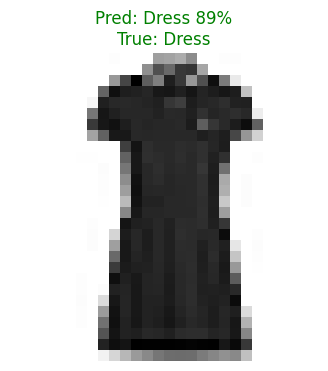

(3657, 'Dress', 'Dress', np.float32(88.943275))

In [30]:
def plot_random_image(model, images, true_labels, classes):
    i = random.randrange(len(images))

    image_to_predict = images[i]
    true_label = classes[true_labels[i]]

    pred_probs = model.predict(np.expand_dims(image_to_predict, axis=0), verbose=0)
    pred_label = classes[np.argmax(pred_probs)]
    pred_confidence = np.max(pred_probs) * 100

    color = "green" if pred_label == true_label else "red"

    plt.figure(figsize=(4, 4))
    plt.imshow(image_to_predict, cmap=plt.cm.binary)
    plt.title(
        f"Pred: {pred_label} {pred_confidence:.0f}%\nTrue: {true_label}",
        color=color
    )
    plt.axis("off")
    plt.show()

    return i, pred_label, true_label, pred_confidence


plot_random_image(model_4, test_data_norm, test_labels, class_names)